In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import pyfixest as pf


import os

folder_path = "../output/simulations_irf"

<Axes: xlabel='year'>

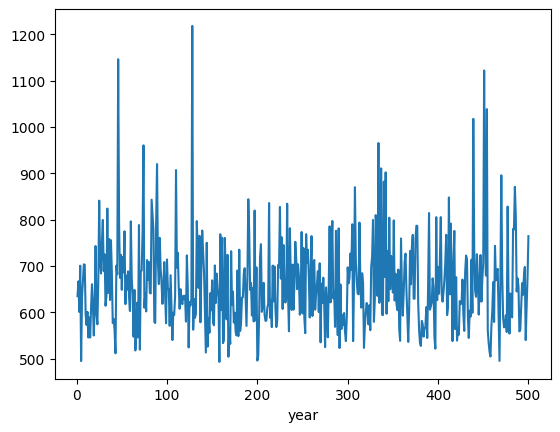

In [8]:
panel_c.groupby('year').D.mean().plot()

Text(0.5, 1.0, 'Dynamic correction')

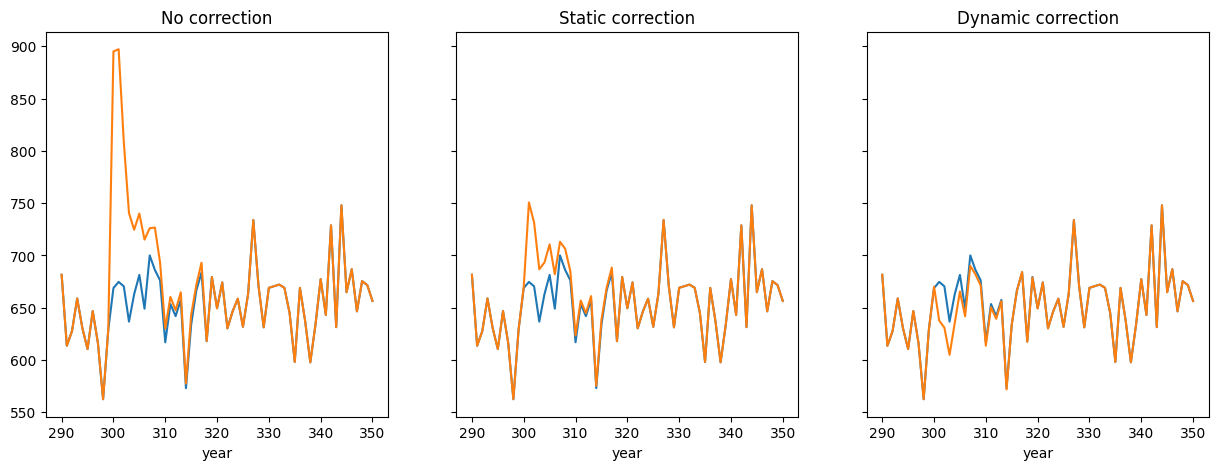

In [15]:
panel = pd.read_parquet(os.path.join(folder_path,"panel.parquet"))
panel_c = panel.query('group == "control"')
panel_t = panel.query('treatment  == "none" & group == "treatment"')
panel_t_s = panel.query('treatment == "static"')
panel_t_d = panel.query('treatment == "dynamic"')



fig,ax = plt.subplots(1,3,figsize= (15,5),sharey = True)
panel_c.query('350 >= year >= 290').groupby('year').D.mean().plot(ax = ax[0])
panel_t.query('350 >= year >= 290').groupby('year').D.mean().plot(ax = ax[0])
ax[0].set_title('No correction')

panel_c.query('350 >= year >= 290').groupby('year').D.mean().plot(ax = ax[1])
panel_t_s.query('350 >= year >= 290').groupby('year').D.mean().plot(ax = ax[1])
ax[1].set_title('Static correction')

panel_c.query('350 >= year >= 290').groupby('year').D.mean().plot(ax = ax[2])
panel_t_d.query('350 >= year >= 290').groupby('year').D.mean().plot(ax = ax[2])
ax[2].set_title('Dynamic correction')

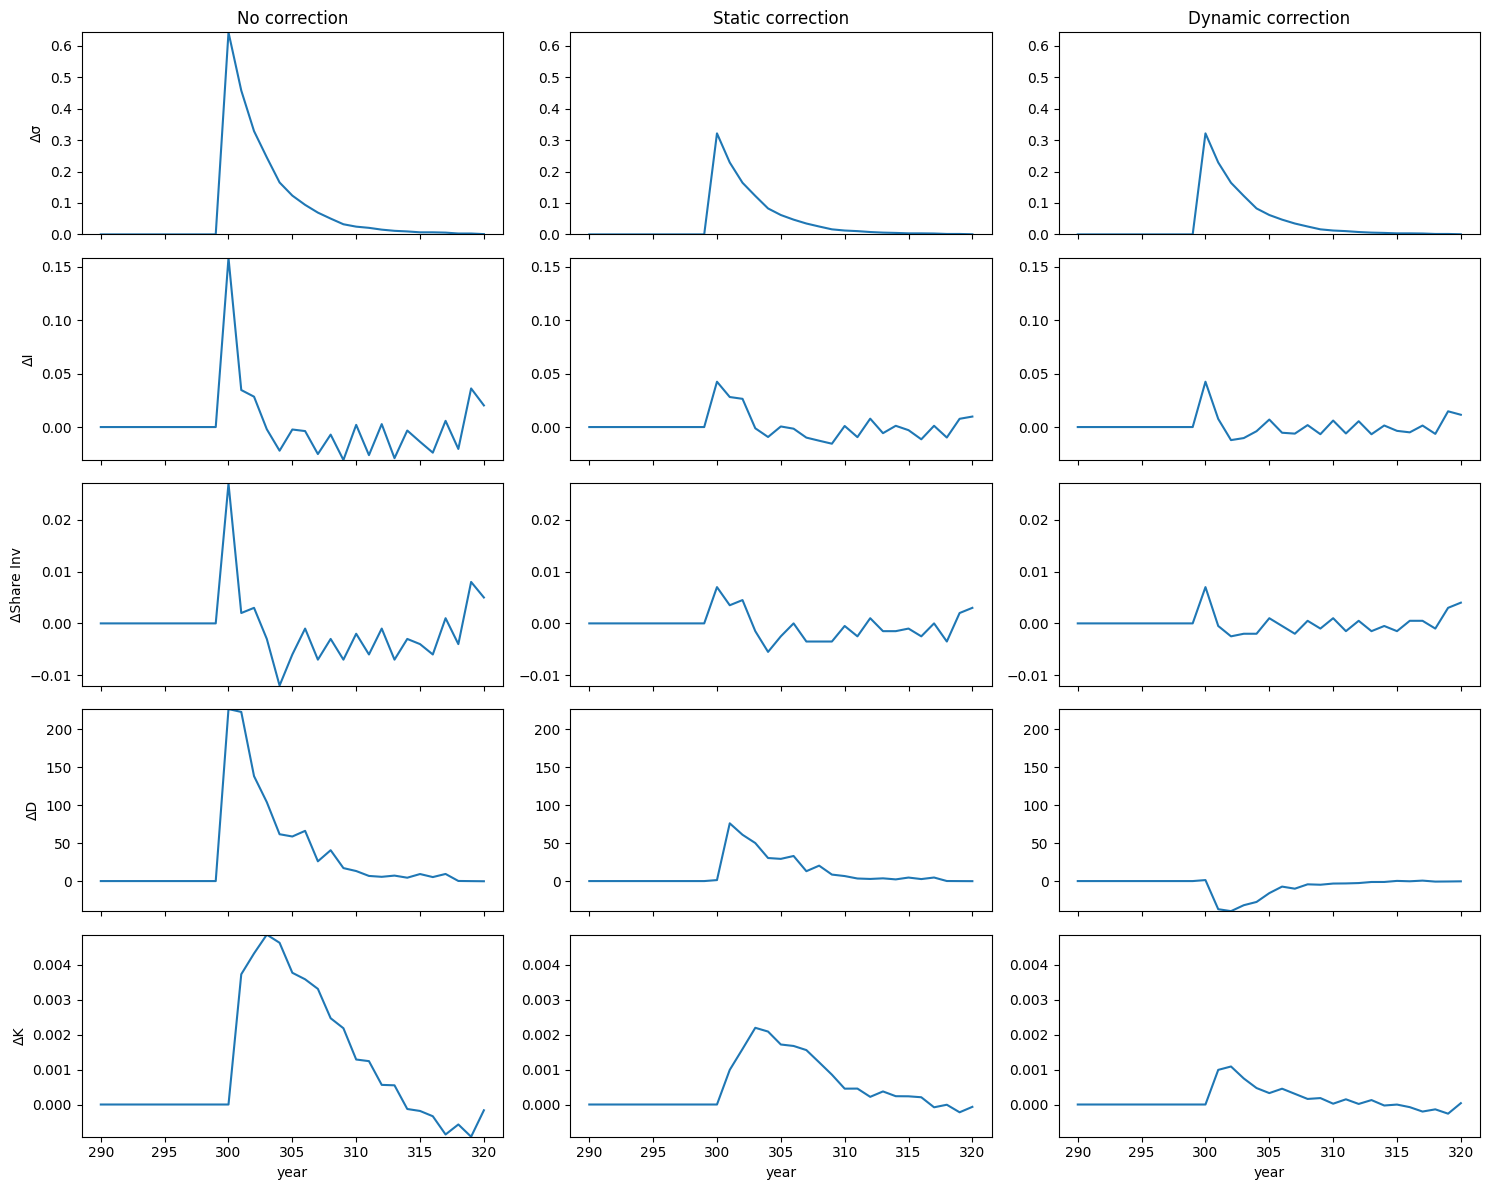

In [16]:
def compute_deltas(panel_treatment, panel_control):
    panel = panel_treatment[['firm_id','year','sigma',"I","D","K","I_rate"]].merge(
        panel_control[['firm_id','year','sigma',"I","D","K","I_rate"]],
        on=['firm_id','year'],
        suffixes=['_t','_c']
    ).query('320 >= year >= 290')

    panel['delta_sigma'] = panel.sigma_t - panel.sigma_c
    panel['delta_I'] = panel.I_rate_t - panel.I_rate_c
    panel['delta_share_inv'] = (panel.I_rate_t > 0).astype(int) - (panel.I_rate_c > 0).astype(int)
    panel['delta_D'] = panel.D_t - panel.D_c
    panel['delta_K'] = panel.K_t - panel.K_c

    return {
        'Δσ': panel.groupby('year')['delta_sigma'].mean(),
        'ΔI': panel.groupby('year')['delta_I'].mean(),
        'ΔShare Inv': panel.groupby('year')['delta_share_inv'].mean(),
        'ΔD': panel.groupby('year')['delta_D'].mean(),
        'ΔK': panel.groupby('year')['delta_K'].mean()
    }


cases = {
    "No correction": panel_t,
    "Static correction": panel_t_s,
    "Dynamic correction": panel_t_d
}

results = {name: compute_deltas(treat, panel_c) for name, treat in cases.items()}

variables = ['Δσ', 'ΔI', 'ΔShare Inv', 'ΔD', 'ΔK']

# --- Compute common y-limits per row (key step) ---
ylims = {}
for var in variables:
    all_values = []
    for case in results.values():
        all_values.append(case[var])
    combined = pd.concat(all_values)
    ylims[var] = (combined.min(), combined.max())

# --- Plot ---
fig, axes = plt.subplots(len(variables), 3, figsize=(15, 12), sharex=True)

for col_idx, (case_name, res) in enumerate(results.items()):
    for row_idx, var in enumerate(variables):
        ax = axes[row_idx, col_idx]
        res[var].plot(ax=ax)

        # enforce identical y-scale within row
        ax.set_ylim(ylims[var])

        if row_idx == 0:
            ax.set_title(case_name)

        if col_idx == 0:
            ax.set_ylabel(var)

plt.tight_layout()
plt.show()

In [79]:
pf.feols("I_rate  ~ sigma  + D",data = panel_control).summary()

###

Estimation:  OLS
Dep. var.: I_rate, Fixed effects: 0
Inference:  iid
Observations:  500000

| Coefficient   |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:--------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| Intercept     |      0.205 |        0.007 |    28.895 |      0.000 |  0.191 |   0.219 |
| sigma         |      0.281 |        0.012 |    24.176 |      0.000 |  0.258 |   0.304 |
| D             |      0.000 |        0.000 |    88.082 |      0.000 |  0.000 |   0.001 |
---
RMSE: 3.582 R2: 0.019 
